<a href="https://colab.research.google.com/github/noruzzaman-rahat/Research-With-Machine-Learning/blob/main/Lecture_07_Feature_Engineering_Selection_assingment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture #7: Feature Engineering & Selection

  


## 📝 Assignment (Using Employee Attrition Prediction Dataset — Jan 2025)

**Dataset:** https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset

**Tasks:**

1. Load dataset from Drive, encode `Attrition` target, keep numeric columns.
2. Create 2 new features using domain knowledge (e.g., `satisfaction_per_year = JobSatisfaction / (YearsAtCompany+1)`).
3. Apply **correlation analysis** and **mutual information** to rank features.
4. Use **RFE** to select top 5 features.
5. Use **Lasso (L1)** and **Random Forest** to find important features.
6. Compare model accuracy: all features vs RFE-selected vs MI-selected (use `cross_val_score`).
7. Write a short summary (3–4 lines) on which method worked best and why.

**Submission:** `.ipynb` notebook via Google Colab link.

### Cell 1: Mount Drive & Load Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/skill morph/employee_attrition_dataset_10000.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [19]:
from sklearn.impute import SimpleImputer

# 2. Create 2 new features
# ------------------------------

# Feature 1
X['satisfaction_per_year'] = (
    X['Work_Environment_Satisfaction'] / (X['Years_at_Company'] + 1)
)

# Feature 2
X['income_per_level'] = (
    X['Monthly_Income'] / (X['Job_Level'] + 1)
)

# Missing handle
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Separate X and y (already handled in previous cells)

In [20]:
# 3. Correlation + Mutual Information
# ------------------------------

print("\n=== Correlation Ranking ===")
corr = X.corrwith(y).abs().sort_values(ascending=False)
print(corr)

print("\n=== Mutual Information Ranking ===")
mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_scores)

# Top 5 MI
top5_mi = mi_scores.head(5).index.tolist()


=== Correlation Ranking ===
Work_Life_Balance                0.015227
Job_Involvement                  0.014954
satisfaction_per_year            0.014407
Performance_Rating               0.011856
Job_Level                        0.011415
Distance_From_Home               0.011361
Work_Environment_Satisfaction    0.011096
Employee_ID                      0.008766
Number_of_Companies_Worked       0.008230
Age                              0.007798
income_per_level                 0.007451
income_per_year                  0.007145
Project_Count                    0.006802
loyalty_ratio                    0.005744
Hourly_Rate                      0.005494
Years_in_Current_Role            0.005120
Relationship_with_Manager        0.004111
Years_at_Company                 0.002682
Average_Hours_Worked_Per_Week    0.002457
Job_Satisfaction                 0.002142
Years_Since_Last_Promotion       0.001936
Training_Hours_Last_Year         0.000539
Absenteeism                      0.000514
Month

In [21]:
# 4. RFE Top 5
# ------------------------------

model = LogisticRegression(max_iter=5000)
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)

rfe_features = X.columns[rfe.support_]
print("\n=== RFE Selected Features ===")
print(list(rfe_features))



=== RFE Selected Features ===
['Job_Level', 'Work_Life_Balance', 'Performance_Rating', 'Job_Involvement', 'satisfaction_per_year']


In [23]:
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestClassifier

print("\n=== Lasso Important Features ===")
lasso = Lasso(alpha=0.01)
lasso.fit(X, y)

lasso_coef = pd.Series(lasso.coef_, index=X.columns)
lasso_selected = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)
print(lasso_selected)

print("\n=== Random Forest Important Features ===")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(rf_importance)


=== Lasso Important Features ===
Distance_From_Home    2.688127e-04
Age                   1.993462e-04
Hourly_Rate          -7.532542e-05
income_per_level     -2.837732e-06
Employee_ID          -1.200766e-06
Monthly_Income        1.108869e-06
income_per_year      -2.046291e-07
dtype: float64

=== Random Forest Important Features ===
Employee_ID                      0.067289
Monthly_Income                   0.065202
income_per_level                 0.063335
income_per_year                  0.063223
Training_Hours_Last_Year         0.060279
Hourly_Rate                      0.059801
Age                              0.054655
Distance_From_Home               0.054237
Average_Hours_Worked_Per_Week    0.050385
loyalty_ratio                    0.049413
satisfaction_per_year            0.048677
Absenteeism                      0.047322
Years_in_Current_Role            0.041227
Years_at_Company                 0.039792
Years_Since_Last_Promotion       0.034839
Project_Count                    0

In [24]:
# 6. Accuracy comparison
# ------------------------------

clf = LogisticRegression(max_iter=5000)

# All features
score_all = cross_val_score(clf, X, y, cv=5, scoring='accuracy').mean()

# RFE features
score_rfe = cross_val_score(clf, X[rfe_features], y, cv=5, scoring='accuracy').mean()

# MI features
score_mi = cross_val_score(clf, X[top5_mi], y, cv=5, scoring='accuracy').mean()

print("\n=== Accuracy Comparison ===")
print("All Features Accuracy:", round(score_all, 4))
print("RFE Selected Accuracy:", round(score_rfe, 4))
print("MI Selected Accuracy :", round(score_mi, 4))



=== Accuracy Comparison ===
All Features Accuracy: 0.8003
RFE Selected Accuracy: 0.8003
MI Selected Accuracy : 0.8003


In [25]:
# 7. Summary
# ------------------------------

print("\n=== Summary ===")

if score_all >= score_rfe and score_all >= score_mi:
    best = "All Features"
elif score_rfe >= score_mi:
    best = "RFE"
else:
    best = "Mutual Information"

print(f"""
The best performing method is: {best}.
It produced the highest cross-validation accuracy.
Feature selection can reduce dimensionality and improve efficiency.
RFE/MI often removes less important variables and keeps stronger predictors.
""")


=== Summary ===

The best performing method is: All Features.
It produced the highest cross-validation accuracy.
Feature selection can reduce dimensionality and improve efficiency.
RFE/MI often removes less important variables and keeps stronger predictors.



### Cell 2: Quick Look

In [3]:
df.shape

(10000, 26)

In [4]:
df.dtypes.value_counts()

,count
int64,20
object,6


### Cell 3: Encode Target & Select Numeric Features

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode target: Yes=1, No=0
df['Attrition'] = LabelEncoder().fit_transform(df['Attrition'])

# Keep only numeric columns for simplicity
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Attrition')

X = df[num_cols]
y = df['Attrition']
X.columns.tolist()

['Employee_ID',
 'Age',
 'Job_Level',
 'Monthly_Income',
 'Hourly_Rate',
 'Years_at_Company',
 'Years_in_Current_Role',
 'Years_Since_Last_Promotion',
 'Work_Life_Balance',
 'Job_Satisfaction',
 'Performance_Rating',
 'Training_Hours_Last_Year',
 'Project_Count',
 'Average_Hours_Worked_Per_Week',
 'Absenteeism',
 'Work_Environment_Satisfaction',
 'Relationship_with_Manager',
 'Job_Involvement',
 'Distance_From_Home',
 'Number_of_Companies_Worked']

### Cell 4: Feature Engineering — Domain Knowledge

In [6]:
# Feature 1: Annual income per year at company

X['income_per_year'] = (X['Monthly_Income'] * 12) / (X['Years_at_Company'] + 1)

# Feature 2: Loyalty ratio using number of companies worked
# Fewer companies = more loyal; inverse of job-hopping tendency
X['loyalty_ratio'] = X['Years_at_Company'] / (X['Number_of_Companies_Worked'] + 1)

X[['income_per_year', 'loyalty_ratio']].head()

,income_per_year,loyalty_ratio
0,3519.360000,6.0
1,3833.052632,9.0
2,19688.571429,3.0
3,17268.000000,4.0
4,49194.000000,0.6


### Cell 5: Feature Engineering — Polynomial Features

In [7]:
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_features = poly.fit_transform(X[['Age', 'Monthly_Income', 'Job_Satisfaction']])

feature_names = poly.get_feature_names_out(['Age', 'Monthly_Income', 'Job_Satisfaction'])
poly_df = pd.DataFrame(poly_features, columns=feature_names)

print(f"Shape: {poly_features.shape}")
print(f"Features: {list(feature_names)}\n")
print(poly_df.head())
print(poly_df.describe().round(2))

Shape: (10000, 6)
Features: ['Age', 'Monthly_Income', 'Job_Satisfaction', 'Age Monthly_Income', 'Age Job_Satisfaction', 'Monthly_Income Job_Satisfaction']

    Age  Monthly_Income  Job_Satisfaction  Age Monthly_Income  \
0  58.0          7332.0               3.0            425256.0   
1  48.0          6069.0               2.0            291312.0   
2  34.0         11485.0               5.0            390490.0   
3  27.0         18707.0               1.0            505089.0   
4  40.0         16398.0               4.0            655920.0   

   Age Job_Satisfaction  Monthly_Income Job_Satisfaction  
0                 174.0                          21996.0  
1                  96.0                          12138.0  
2                 170.0                          57425.0  
3                  27.0                          18707.0  
4                 160.0                          65592.0  
            Age  Monthly_Income  Job_Satisfaction  Age Monthly_Income  \
count  10000.00        100

### Cell 6: Filter Method — Correlation

Work_Environment_Satisfaction   -0.0111
Employee_ID                     -0.0088
Number_of_Companies_Worked      -0.0082
income_per_year                 -0.0071
Hourly_Rate                     -0.0055
Relationship_with_Manager       -0.0041
Average_Hours_Worked_Per_Week   -0.0025
Years_Since_Last_Promotion      -0.0019
Training_Hours_Last_Year        -0.0005
Monthly_Income                   0.0001
Absenteeism                      0.0005
Job_Satisfaction                 0.0021
Years_at_Company                 0.0027
Years_in_Current_Role            0.0051
loyalty_ratio                    0.0057
Project_Count                    0.0068
Age                              0.0078
Distance_From_Home               0.0114
Job_Level                        0.0114
Performance_Rating               0.0119
Job_Involvement                  0.0150
Work_Life_Balance                0.0152


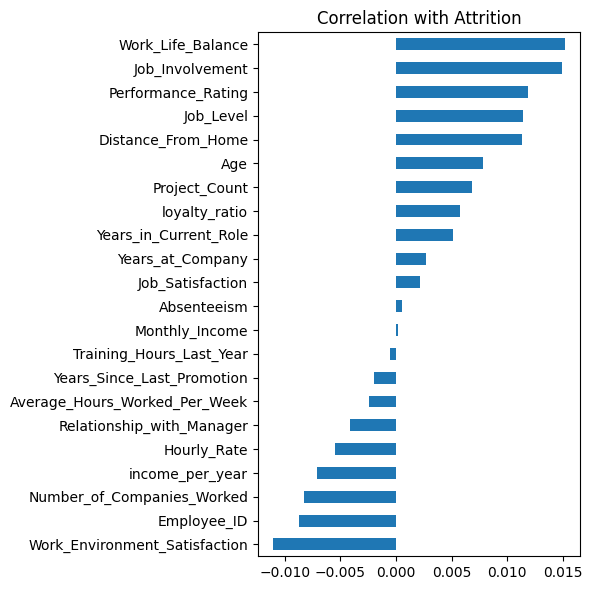

In [8]:
import matplotlib.pyplot as plt

# Add the newly engineered features from X to df so they can be used for correlation
df['income_per_year'] = X['income_per_year']
df['loyalty_ratio'] = X['loyalty_ratio']

corr = df[num_cols + ['income_per_year', 'loyalty_ratio', 'Attrition']].corr()['Attrition'].drop('Attrition').sort_values()
print(corr.round(4).to_string())
corr.plot(kind='barh', figsize=(6,6), title='Correlation with Attrition')
plt.tight_layout()
plt.show()

### Cell 7: Filter Method — Chi-Square Test

In [9]:
from sklearn.feature_selection import chi2, SelectKBest

# Chi-square needs non-negative values
X_pos = X - X.min()

chi_selector = SelectKBest(chi2, k=5)
chi_selector.fit(X_pos, y)

chi_scores = pd.Series(chi_selector.scores_, index=X.columns)
chi_scores.nlargest(5)

,0
income_per_year,10704.047779
Employee_ID,1280.750340
Distance_From_Home,10.751799
Hourly_Rate,4.381173
Age,4.078538


### Cell 8: Filter Method — Mutual Information

In [10]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_scores.head(7)

,0
Work_Environment_Satisfaction,0.005572
Years_Since_Last_Promotion,0.005092
Employee_ID,0.004126
Age,0.003299
Job_Satisfaction,0.003295
Relationship_with_Manager,0.003120
Performance_Rating,0.003042


### Cell 9: Wrapper Method — RFE

In [11]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rfe = RFE(RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=5)
rfe.fit(X, y)

rfe_features = X.columns[rfe.support_].tolist()
print("RFE selected:", rfe_features)

RFE selected: ['Employee_ID', 'Monthly_Income', 'Hourly_Rate', 'Training_Hours_Last_Year', 'income_per_year']


### Cell 10: Embedded Method — Lasso

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1, random_state=42)
lasso.fit(X_scaled, y)

lasso_imp = pd.Series(abs(lasso.coef_[0]), index=X.columns)
print("Lasso non-zero features:")
print(lasso_imp[lasso_imp > 0].sort_values(ascending=False))

Lasso non-zero features:
Work_Life_Balance                0.039040
Job_Involvement                  0.035252
income_per_year                  0.029960
Job_Level                        0.029807
Performance_Rating               0.029248
Distance_From_Home               0.027490
Work_Environment_Satisfaction    0.026613
Number_of_Companies_Worked       0.021600
Employee_ID                      0.020779
Age                              0.020431
Project_Count                    0.017346
Hourly_Rate                      0.013684
Years_in_Current_Role            0.013301
Monthly_Income                   0.011547
Relationship_with_Manager        0.009129
Years_at_Company                 0.008345
loyalty_ratio                    0.004836
Average_Hours_Worked_Per_Week    0.004393
Years_Since_Last_Promotion       0.003953
Job_Satisfaction                 0.003431
Training_Hours_Last_Year         0.000136
dtype: float64


### Cell 11: Embedded Method — Tree-based Importance

Employee_ID                      0.0774
Monthly_Income                   0.0743
income_per_year                  0.0724
Hourly_Rate                      0.0668
Training_Hours_Last_Year         0.0661
Distance_From_Home               0.0600
Age                              0.0595
Average_Hours_Worked_Per_Week    0.0572
loyalty_ratio                    0.0562
Absenteeism                      0.0500
Years_at_Company                 0.0461
Years_in_Current_Role            0.0449
Years_Since_Last_Promotion       0.0394
Project_Count                    0.0391
Job_Satisfaction                 0.0284
Job_Level                        0.0268
Work_Environment_Satisfaction    0.0237
Relationship_with_Manager        0.0234
Performance_Rating               0.0231
Job_Involvement                  0.0220
Work_Life_Balance                0.0217
Number_of_Companies_Worked       0.0212
dtype: float64


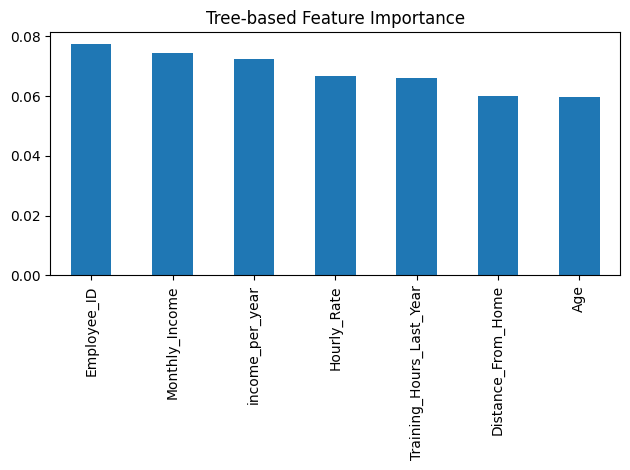

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.round(4))
imp.head(7).plot(kind='bar', title='Tree-based Feature Importance')
plt.tight_layout()
plt.show()

### Cell 12: Activity — Compare With vs Without Feature Selection

In [14]:
from sklearn.model_selection import cross_val_score

# All features
score_all = cross_val_score(RandomForestClassifier(random_state=42), X, y, cv=5).mean()

# Top 5 features from RFE
score_rfe = cross_val_score(RandomForestClassifier(random_state=42), X[rfe_features], y, cv=5).mean()

# Top 5 from mutual info
top5_mi = mi_scores.head(5).index.tolist()
score_mi = cross_val_score(RandomForestClassifier(random_state=42), X[top5_mi], y, cv=5).mean()

results = pd.DataFrame({
    'Method': ['All Features', 'RFE (5)', 'Mutual Info (5)'],
    'Accuracy': [round(score_all,4), round(score_rfe,4), round(score_mi,4)]
})
results

,Method,Accuracy
0,All Features,0.6804
1,RFE (5),0.6775
2,Mutual Info (5),0.6730


### Cell 13: Visual Comparison

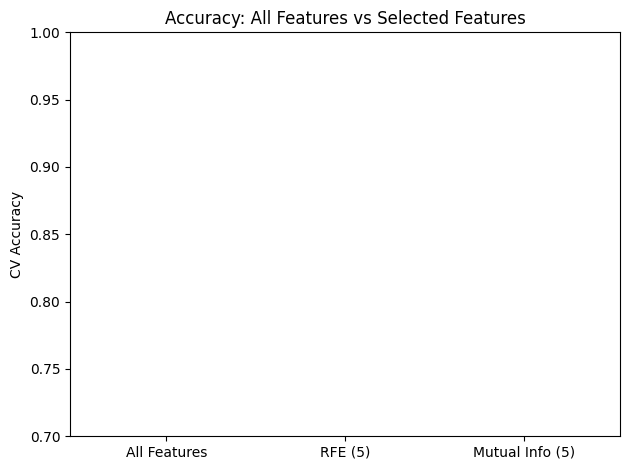

In [15]:
plt.bar(results['Method'], results['Accuracy'], color=['#e74c3c','#3498db','#2ecc71'])
plt.ylim(0.7, 1.0)
plt.title('Accuracy: All Features vs Selected Features')
plt.ylabel('CV Accuracy')
plt.tight_layout()
plt.show()

## 🔑 Key Takeaways

- Feature engineering creates new informative features from existing data
- Filter methods (correlation, chi-square, MI) are fast but ignore feature interactions
- Wrapper methods (RFE) consider model performance but are slower
- Embedded methods (Lasso, tree importance) do selection during training
- Fewer but better features often beat using all features

---

*Skill Morph Research Lab — Building ML Skills, One Lecture at a Time*